## Install SQL and Check Data

In [1]:
pip install pandas sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    "postgresql+psycopg2",
    username = "postgres",
    password = "G1g1g2g6z()&$",
    host = "127.0.0.1",
    port = 5432,
    database = "Student Information"
)

engine = create_engine(connection_url)

with engine.connect() as connection:
    print("Connected!")

Connected!


In [3]:
import pandas as pd 
import matplotlib.pyplot as plt

In [4]:
df = pd.read_sql(
    "Select * From student_information_data;",
    engine
)

df

,student_id,name,age,email,department,gpa,graduation_year
0,3336,David Palmer,19,sean43@hotmail.com,Mathematics,3.16,2026
1,8774,Andrew Roach,23,vbecker@harvey.com,Chemistry,3.75,2027
2,1396,Jonathan Gonzalez,22,hollydavis@gmail.com,Physics,2.95,2027
3,6716,Kenneth Morrow,24,ganderson@wheeler-atkins.info,Physics,3.55,2029
4,8830,Kaitlyn Martinez,18,hayesdiane@gmail.com,Chemistry,2.29,2025
...,...,...,...,...,...,...,...
195,3274,Catherine Velasquez,22,fsutton@gmail.com,Physics,2.71,2025
196,3609,Joyce Thomas,19,zanderson@barrera.net,Chemistry,2.22,2030
197,9179,Theresa Hughes,21,mstanley@yahoo.com,Mathematics,3.23,2025
198,4463,Steven Golden,19,nvasquez@yahoo.com,Computer Science,3.90,2025


In [5]:
df.head()

,student_id,name,age,email,department,gpa,graduation_year
0,3336,David Palmer,19,sean43@hotmail.com,Mathematics,3.16,2026
1,8774,Andrew Roach,23,vbecker@harvey.com,Chemistry,3.75,2027
2,1396,Jonathan Gonzalez,22,hollydavis@gmail.com,Physics,2.95,2027
3,6716,Kenneth Morrow,24,ganderson@wheeler-atkins.info,Physics,3.55,2029
4,8830,Kaitlyn Martinez,18,hayesdiane@gmail.com,Chemistry,2.29,2025


In [6]:
df.shape

(200, 7)

In [7]:
df.isnull().sum()

student_id         0
name               0
age                0
email              0
department         0
gpa                0
graduation_year    0
dtype: int64

## 1. What does the distribution of students GPAs look like?

In [8]:
df["gpa"].describe()

count    200.00000
mean       3.02785
std        0.59112
min        2.00000
25%        2.52500
50%        3.08000
75%        3.51000
max        3.99000
Name: gpa, dtype: float64

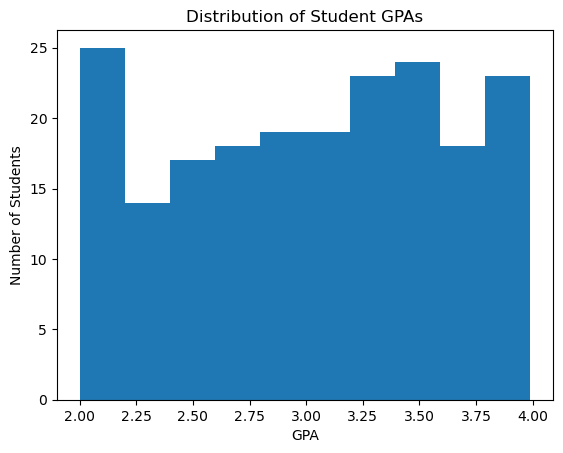

In [9]:
df["gpa"].plot(kind = "hist", bins = 10)

plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.title("Distribution of Student GPAs")
plt.show()

## 2. How is student age distributed?

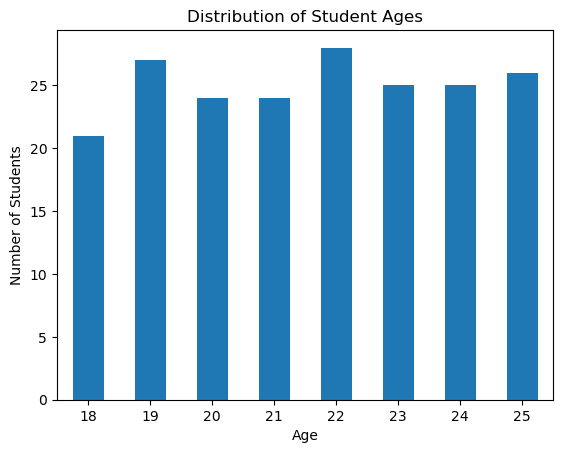

In [10]:
age_counts = df["age"].value_counts().sort_index()

age_counts.plot(kind = "bar")

plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Ages")
plt.xticks(rotation = 0)
plt.show()

## 3. Is there a relationship between age and GPA?

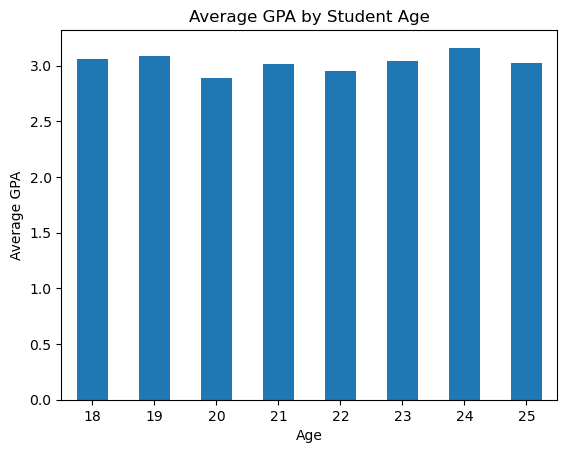

In [11]:
avg_gpa_by_age = df.groupby("age")["gpa"].mean().round(2)

avg_gpa_by_age.plot(kind = "bar")

plt.xlabel("Age")
plt.ylabel("Average GPA")
plt.title("Average GPA by Student Age")
plt.xticks(rotation = 0)
plt.show()

## 4. How does GPA vary across departments?

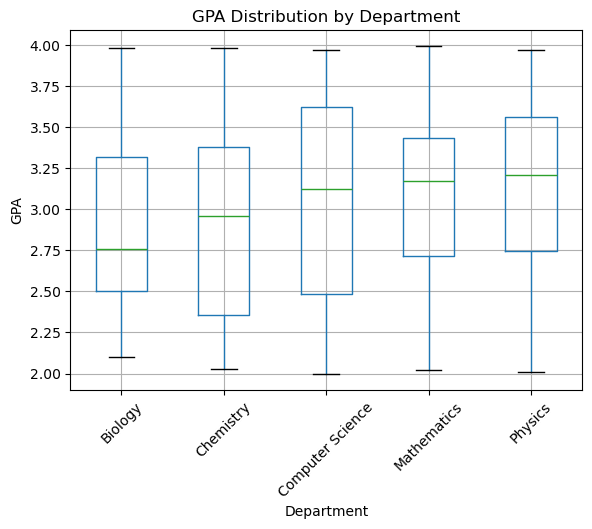

In [12]:
df.boxplot(column = "gpa", by = "department")

plt.xlabel("Department")
plt.ylabel("GPA")
plt.title("GPA Distribution by Department")
plt.suptitle("")
plt.xticks(rotation = 45)
plt.show()

## 5. What is the relationship between student age and graduation year?

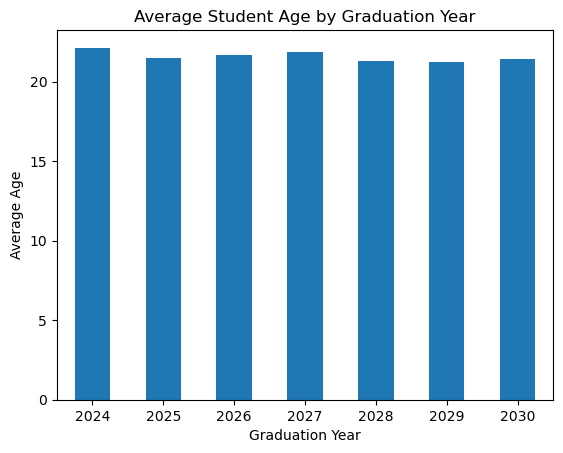

In [13]:
avg_age_by_year = df.groupby("graduation_year")["age"].mean().round(2)

avg_age_by_year.plot(kind = "bar")

plt.xlabel("Graduation Year")
plt.ylabel("Average Age")
plt.title("Average Student Age by Graduation Year")
plt.xticks(rotation = 0)
plt.show()

## 6. How strongly are age, GPA, and graduation year correlated?

In [14]:
correlation = df[["age", "gpa", "graduation_year"]].corr()

correlation

,age,gpa,graduation_year
age,1.000000,0.017922,-0.085804
gpa,0.017922,1.000000,0.013552
graduation_year,-0.085804,0.013552,1.000000


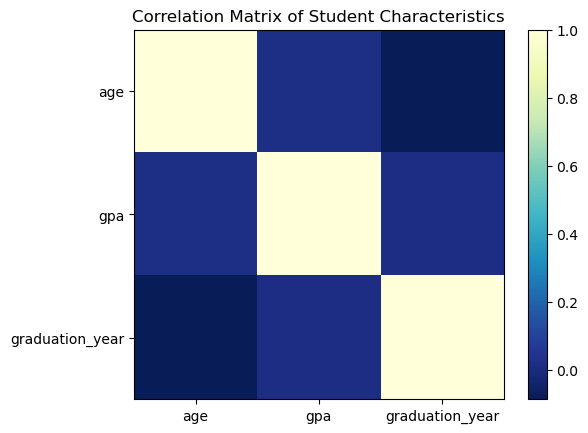

In [20]:
plt.imshow(correlation, cmap = "YlGnBu_r")

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar()
plt.title("Correlation Matrix of Student Characteristics")
plt.show()

## 7. How does GPA vary across different graduation years?

In [21]:
df.groupby("graduation_year")["gpa"].agg(
    ["mean", "median", "min", "max"]
).round(2)

,mean,median,min,max
graduation_year,,,,
2024,3.03,3.16,2.04,3.97
2025,3.00,2.95,2.02,3.90
2026,2.95,3.16,2.02,3.96
2027,3.13,3.24,2.00,3.98
2028,3.01,3.14,2.02,3.92
2029,2.98,2.98,2.10,3.99
2030,3.05,3.05,2.01,3.98


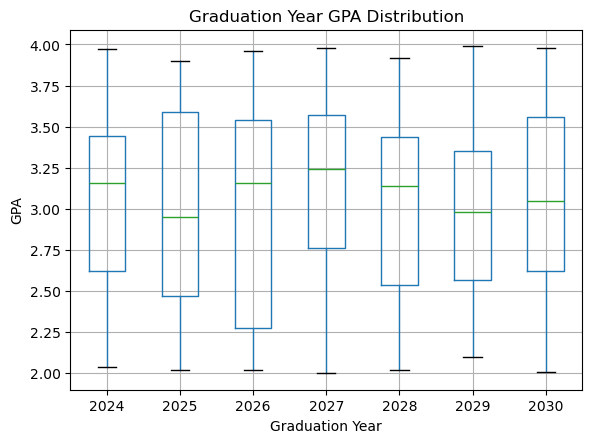

In [22]:
df.boxplot(column = "gpa", by = "graduation_year")

plt.xlabel("Graduation Year")
plt.ylabel("GPA")
plt.title("Graduation Year GPA Distribution")
plt.suptitle("")
plt.show()